In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model= 'gpt-4o-mini')

In [5]:
from langchain_core.messages import HumanMessage,RemoveMessage

In [9]:
def chat(state:MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)

    return {
        'messages':[response]
    }

In [10]:
def delete_old_messages(state:MessagesState):
    messages = state['messages']

    if len(messages)>10:
        to_remove = messages[:6]

        return {'messages':[RemoveMessage(id=m.id) for m in to_remove]}
    return {}

In [11]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [12]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [13]:
graph = builder.compile(checkpointer=InMemorySaver())

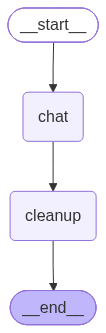

In [14]:
graph

In [15]:
config = {"configurable": {"thread_id": "t1"}}

In [16]:

# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm raju"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='21d0bbd4-1042-4f58-aab5-65b0598fbfa6'),
  AIMessage(content='LangChain is a framework designed for developing applications that use large language models (LLMs). It provides a set of tools and abstractions to facilitate the creation of applications that leverage the capabilities of these models. LangChain is particularly focused on enabling developers to build applications with LLMs in a more structured and scalable way.\n\n### Key Features of LangChain:\n\n1. **Modular Components**: LangChain breaks down the application-building process into modular components. This allows developers to easily incorporate different functionalities, such as data loading, model interaction, and output handling.\n\n2. **Pipelines**: The framework allows developers to create pipelines that define a flow of data through various processing steps. This can include preprocessing input data, passing it to an

In [17]:
snap = graph.get_state(config)

In [19]:
snap

StateSnapshot(values={'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='21d0bbd4-1042-4f58-aab5-65b0598fbfa6'), AIMessage(content='LangChain is a framework designed for developing applications that use large language models (LLMs). It provides a set of tools and abstractions to facilitate the creation of applications that leverage the capabilities of these models. LangChain is particularly focused on enabling developers to build applications with LLMs in a more structured and scalable way.\n\n### Key Features of LangChain:\n\n1. **Modular Components**: LangChain breaks down the application-building process into modular components. This allows developers to easily incorporate different functionalities, such as data loading, model interaction, and output handling.\n\n2. **Pipelines**: The framework allows developers to create pipelines that define a flow of data through various processing steps. This can include preprocessing input dat

In [18]:
print('stored message after deletion ',len(snap.values['messages']))

stored message after deletion  8
